# Stage 1: complete forward calculation, c → detector

This notebook runs the whole Stage 1 forward model one step at a time, using the project modules:

$$c \;\rightarrow\; S(\lambda;c) \;\rightarrow\; E_\text{in}(x,y) \;\rightarrow\; t(x,y)=e^{i\phi} \;\rightarrow\; E(x,y,z;\lambda) \;\rightarrow\; I(x,y;c) \;\rightarrow\; I_A,\, I_B,\, R$$

| Step | Module | What it computes |
|---|---|---|
| 1 | `sensor_model.py` | Lorentzian sensor spectrum $S(\lambda;c)$ |
| 2 | `doe.py` | Phase-only DOE $t = e^{i\phi(x,y)}$ (linear grating for validation) |
| 3 | `propagation.py` | Gaussian input beam and the field after the DOE |
| 4 | `propagation.py` | Band-limited angular-spectrum propagation at every wavelength |
| 5 | `detector.py` | Broadband intensity $I = \sum_k S(\lambda_k;c)\,|E(\lambda_k)|^2\,\Delta\lambda$ and detector signals |

All parameters come from `src/config.py`. No optimization is performed in Stage 1.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))          # project modules live in ../src
warnings.filterwarnings("ignore", category=FutureWarning)

import math
import matplotlib.pyplot as plt
import torch

from config import CFG
from sensor_model import resonance_wavelength
from doe import linear_grating
from propagation import grid_for_doe, embed_phase, gaussian_beam, apply_doe, angular_spectrum, power
from detector import (broadband_intensity, monochromatic_intensity, rect_mask, region_power,
                      differential_readout, centroid, cross_section)

UM, MM = 1e6, 1e3
plt.rcParams.update({"figure.dpi": 100, "font.size": 9})

cfg = CFG
print(f"Sensor : lambda0 = {cfg.lambda0_nm} nm, FWHM = {cfg.fwhm_nm} nm, A = {cfg.depth}, "
      f"alpha = {cfg.shift_per_c_nm} nm per unit c, source FWHM = {cfg.source_fwhm_nm} nm")
print(f"DOE    : {cfg.n_doe} x {cfg.n_doe} pixels, pitch {cfg.pitch*UM:.0f} um, grating period {cfg.period*UM:.0f} um")
print(f"Optics : w0 = {cfg.w0*UM:.0f} um, z = {cfg.z*MM:.0f} mm, {cfg.upsample} samples per DOE pixel")

Sensor : lambda0 = 1550.0 nm, FWHM = 5.0 nm, A = 0.8, alpha = 2.5 nm per unit c, source FWHM = 20.0 nm
DOE    : 256 x 256 pixels, pitch 10 um, grating period 160 um
Optics : w0 = 200 um, z = 50 mm, 2 samples per DOE pixel


## Step 1: sensor spectrum $S(\lambda;c)$

The resonance moves linearly with concentration, $\lambda_r(c) = \lambda_0 + \alpha c$, and cuts a Lorentzian dip
$T(\lambda;c) = 1 - A/\{1+[(\lambda-\lambda_r)/\gamma]^2\}$ into a Gaussian source. One unit of $c$ shifts the resonance by one half-width $\gamma = 2.5$ nm.

9 concentrations, 150 wavelengths 1520.0-1585.0 nm, d_lambda = 0.436 nm
lambda_r(c) [nm]: [1550.0, 1550.63, 1551.25, 1551.88, 1552.5, 1553.12, 1553.75, 1554.38, 1555.0]


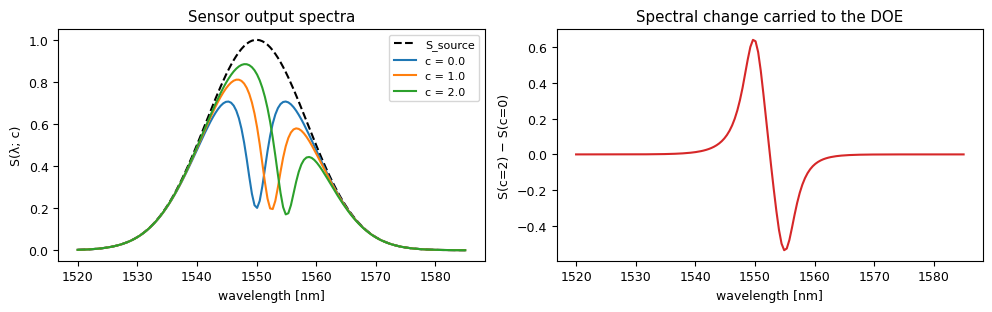

In [2]:
sensor = cfg.sensor()                                  # normalized units, lambda0 = 1
c = torch.linspace(0, cfg.c_max, 9, dtype=torch.float64)
S = sensor.spectrum(c)                                 # shape (Nc, Nlambda)
lam_nm = sensor.lam * cfg.lambda0_nm
lam_m = cfg.lam_m(sensor)                              # metres, for propagation
dlam = cfg.dlam_nm(sensor)

print(f"{len(c)} concentrations, {lam_nm.numel()} wavelengths "
      f"{lam_nm[0]:.1f}-{lam_nm[-1]:.1f} nm, d_lambda = {dlam:.3f} nm")
print("lambda_r(c) [nm]:", [round(float(v), 2) for v in resonance_wavelength(c, sensor.params) * cfg.lambda0_nm])

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(lam_nm, sensor.source, "k--", label="S_source")
for k in (0, 4, 8):
    ax[0].plot(lam_nm, S[k], label=f"c = {float(c[k]):.1f}")
ax[0].set(xlabel="wavelength [nm]", ylabel="S(λ; c)", title="Sensor output spectra")
ax[0].legend(fontsize=8)
ax[1].plot(lam_nm, S[8] - S[0], color="C3")
ax[1].set(xlabel="wavelength [nm]", ylabel="S(c=2) − S(c=0)", title="Spectral change carried to the DOE")
fig.tight_layout()
plt.show()

## Step 2: phase-only DOE

For validation the DOE is a blazed linear grating, $\phi = 2\pi x/d \bmod 2\pi$, with $d = 160\ \mu$m = 16 pixels. Its $+1$ order leaves at $\sin\theta_1 = \lambda/d$.

simulation grid 512 x 512, dx = 5.0 um, window 2.56 mm
+1 order angle at 1550 nm: 9.69 mrad


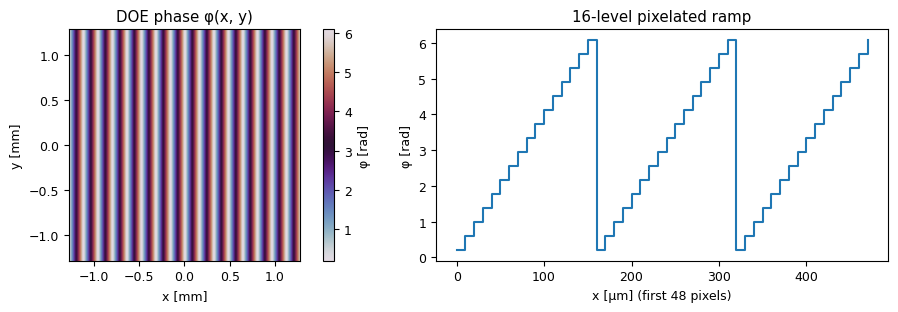

In [3]:
phi_doe = linear_grating(cfg.n_doe, cfg.pitch, cfg.period)      # (256, 256) on DOE pixels
grid = grid_for_doe(cfg.n_doe, cfg.pitch, cfg.upsample, cfg.pad)  # simulation grid
phi = embed_phase(phi_doe, grid, cfg.upsample)                   # each pixel = flat phase step
theta1 = math.asin(cfg.lambda0_nm * 1e-9 / cfg.period)
print(f"simulation grid {grid.n} x {grid.n}, dx = {grid.dx*UM:.1f} um, window {grid.length*MM:.2f} mm")
print(f"+1 order angle at 1550 nm: {theta1*1e3:.2f} mrad")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ext = [-grid.length/2*MM, grid.length/2*MM] * 2
im = ax[0].imshow(phi, extent=ext, origin="lower", cmap="twilight")
fig.colorbar(im, ax=ax[0], label="φ [rad]")
ax[0].set(xlabel="x [mm]", ylabel="y [mm]", title="DOE phase φ(x, y)")
ax[1].step((torch.arange(48) * cfg.pitch * UM), phi_doe[0, :48], where="post")
ax[1].set(xlabel="x [µm] (first 48 pixels)", ylabel="φ [rad]", title="16-level pixelated ramp")
fig.tight_layout()
plt.show()

## Step 3: input field and the field after the DOE

$E_\text{in} = E_0\,e^{-(x^2+y^2)/w_0^2}$ and $E_0^+ = E_\text{in}\,e^{i\phi}$. The DOE is phase-only, so it must not change the optical power.

power in  = 6.283185307e-08   (pi w0^2 / 2 = 6.283185307e-08)
power out = 6.283185307e-08   ratio = 1.000000000000000


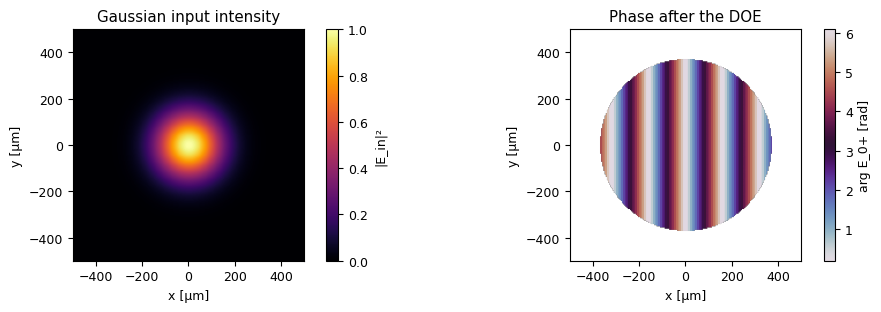

In [4]:
E_in = gaussian_beam(grid, cfg.w0)
E_doe = apply_doe(E_in, phi)
P_in, P_doe = float(power(E_in, grid)), float(power(E_doe, grid))
print(f"power in  = {P_in:.9e}   (pi w0^2 / 2 = {math.pi*cfg.w0**2/2:.9e})")
print(f"power out = {P_doe:.9e}   ratio = {P_doe/P_in:.15f}")

x = grid.x * UM
sel = x.abs() <= 500
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
im = ax[0].imshow((E_in.abs()**2)[sel][:, sel], extent=[-500, 500, -500, 500], origin="lower", cmap="inferno")
fig.colorbar(im, ax=ax[0], label="|E_in|²")
ax[0].set(xlabel="x [µm]", ylabel="y [µm]", title="Gaussian input intensity")
ph = torch.where((E_in.abs()**2) > 1e-3, torch.remainder(torch.angle(E_doe), 2*math.pi), torch.tensor(float("nan"), dtype=torch.float64))
im = ax[1].imshow(ph[sel][:, sel], extent=[-500, 500, -500, 500], origin="lower", cmap="twilight")
fig.colorbar(im, ax=ax[1], label="arg E_0+ [rad]")
ax[1].set(xlabel="x [µm]", ylabel="y [µm]", title="Phase after the DOE")
fig.tight_layout()
plt.show()

## Step 4: wavelength-dependent angular-spectrum propagation

$\tilde E(k_x,k_y,z;\lambda) = \tilde E(k_x,k_y,0)\,e^{i k_z z}$ with $k_z=\sqrt{k^2-k_x^2-k_y^2}$, $k = 2\pi/\lambda$. The grid is the same at every wavelength, so $\lambda$ only enters through $k$. Here three wavelengths are propagated to check the grating equation $x_1 = z\tan\theta_1(\lambda)$.

lambda = 1500 nm : simulated x =  468.772 um, grating equation =  468.771 um, error = 1.34 nm
lambda = 1550 nm : simulated x =  484.399 um, grating equation =  484.398 um, error = 1.47 nm
lambda = 1600 nm : simulated x =  500.027 um, grating equation =  500.025 um, error = 1.62 nm


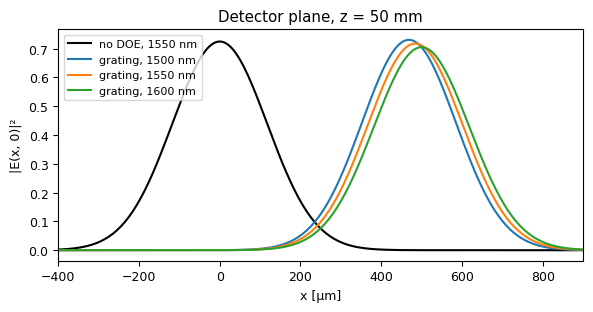

In [5]:
lam_test = torch.tensor([1500e-9, 1550e-9, 1600e-9], dtype=torch.float64)
P = monochromatic_intensity(E_doe, grid, lam_test, cfg.z)       # (3, n, n)
xc = centroid(P, grid)[0]
for l, xs in zip(lam_test, xc):
    x_th = cfg.z * math.tan(math.asin(float(l) / cfg.period))
    print(f"lambda = {float(l)*1e9:.0f} nm : simulated x = {float(xs)*UM:8.3f} um, "
          f"grating equation = {x_th*UM:8.3f} um, error = {abs(float(xs)-x_th)*1e9:.2f} nm")

I_free = monochromatic_intensity(E_in, grid, 1550e-9, cfg.z)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(x, cross_section(I_free, grid), "k", label="no DOE, 1550 nm")
for k, l in enumerate(lam_test):
    ax.plot(x, cross_section(P[k], grid), label=f"grating, {float(l)*1e9:.0f} nm")
ax.set(xlim=(-400, 900), xlabel="x [µm]", ylabel="|E(x, 0)|²", title=f"Detector plane, z = {cfg.z*MM:.0f} mm")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Step 5: broadband detector integration

The spectral components are incoherent, so intensities add: $I(x,y;c) = \sum_k S(\lambda_k;c)\,|E(x,y;\lambda_k)|^2\,\Delta\lambda$. Every wavelength is propagated once and all concentrations are computed together.

broadband intensity: (9, 512, 512)


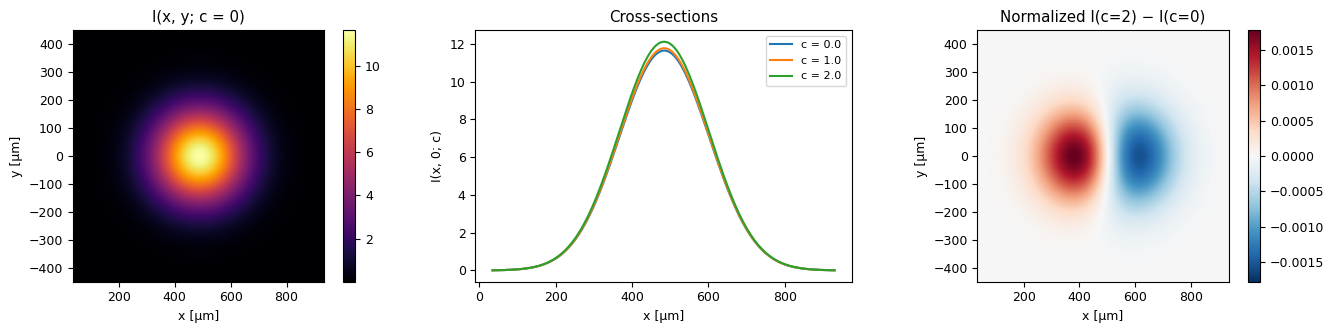

In [6]:
I = broadband_intensity(E_doe, grid, lam_m, cfg.z, S, dlam)     # (Nc, n, n)
print("broadband intensity:", tuple(I.shape))

x0 = cfg.z * math.tan(theta1) * UM
sx, sy = (x - x0).abs() <= 450, x.abs() <= 450
n1, n0 = I[-1] / I[-1].sum(), I[0] / I[0].sum()
dI = (n1 - n0) / n0.max()
v = float(dI.abs().max())
fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
im = ax[0].imshow(I[0][sy][:, sx], extent=[x0-450, x0+450, -450, 450], origin="lower", cmap="inferno")
fig.colorbar(im, ax=ax[0]); ax[0].set(xlabel="x [µm]", ylabel="y [µm]", title="I(x, y; c = 0)")
for k in (0, 4, 8):
    ax[1].plot(x[sx], cross_section(I[k], grid)[sx], label=f"c = {float(c[k]):.1f}")
ax[1].set(xlabel="x [µm]", ylabel="I(x, 0; c)", title="Cross-sections"); ax[1].legend(fontsize=8)
im = ax[2].imshow(dI[sy][:, sx], extent=[x0-450, x0+450, -450, 450], origin="lower", cmap="RdBu_r", vmin=-v, vmax=v)
fig.colorbar(im, ax=ax[2]); ax[2].set(xlabel="x [µm]", ylabel="y [µm]", title="Normalized I(c=2) − I(c=0)")
fig.tight_layout()
plt.show()

## Detector signals: $I_A$, $I_B$ and $R$

Two $300\times600\ \mu$m detectors sit either side of the $+1$ order. The normalized differential readout $R=(I_A-I_B)/(I_A+I_B)$ cancels common source-power changes. The signal is the change $\Delta R = R(c) - R(0)$. This is the end of the forward chain: a number per detector for every concentration.

  c    dR = R(c) - R(0)   centroid shift [nm]
0.00   +0.0000e+00            +0.00
0.25   +3.1637e-04           -48.01
0.50   +6.2697e-04           -95.16
0.75   +9.2640e-04          -140.64
1.00   +1.2096e-03          -183.68
1.25   +1.4722e-03          -223.61
1.50   +1.7104e-03          -259.85
1.75   +1.9212e-03          -291.96
2.00   +2.1026e-03          -319.61


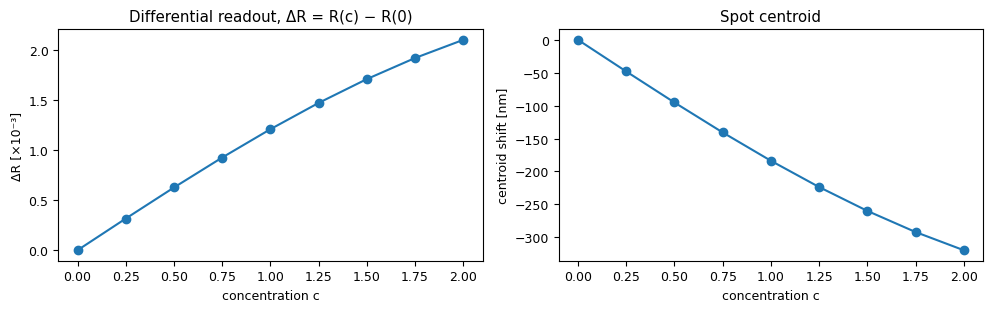

In [7]:
mA = rect_mask(grid, x0/UM - cfg.det_width/2, 0, cfg.det_width, cfg.det_height)
mB = rect_mask(grid, x0/UM + cfg.det_width/2, 0, cfg.det_width, cfg.det_height)
IA, IB = region_power(I, mA, grid), region_power(I, mB, grid)
R = differential_readout(IA, IB)
xc = centroid(I, grid)[0]

dR = R - R[0]                                          # change of the readout with c

print("  c    dR = R(c) - R(0)   centroid shift [nm]")
for k in range(len(c)):
    print(f"{float(c[k]):4.2f}   {float(dR[k]):+.4e}       {float((xc[k]-xc[0])*1e9):+10.2f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(c, dR * 1e3, "o-"); ax[0].set(xlabel="concentration c", ylabel="ΔR [×10⁻³]", title="Differential readout, ΔR = R(c) − R(0)")
ax[1].plot(c, (xc - xc[0]) * 1e9, "o-"); ax[1].set(xlabel="concentration c", ylabel="centroid shift [nm]", title="Spot centroid")
fig.tight_layout()
plt.show()

## The same calculation in one call

`main.forward(c)` chains Steps 1–5 in a single function. It must reproduce the step-by-step result exactly.

In [8]:
from main import forward

r = forward(c)
assert torch.allclose(r["I"], I) and torch.allclose(r["R"], R)
print("main.forward(c) reproduces the step-by-step calculation.")
print(f"one-linewidth shift (c = 0 -> 1): dR = {float(dR[4]):.3e}, centroid shift = {float((xc[4]-xc[0])*1e9):.1f} nm")

main.forward(c) reproduces the step-by-step calculation.
one-linewidth shift (c = 0 -> 1): dR = 1.210e-03, centroid shift = -183.7 nm


## Summary

- Concentration enters only through the sensor spectrum $S(\lambda;c)$. The optics (DOE, propagation) is computed once per wavelength and never depends on $c$.
- The DOE conserves power, and the propagated $+1$ order lands where the grating equation predicts.
- The broadband detector image changes smoothly with $c$: the spot moves toward shorter wavelengths and the power-normalized difference is a dipole.
- With this conventional grating the response is small (about $10^{-3}$ in $R$ per linewidth of shift). This is the baseline that inverse design must improve on in Stage 2.

Full validation tests and convergence studies: `python src/validation.py`. Completion-criterion checks: `python src/completion_check.py`.